# IWSLT14 German → English Transformer (Phase 2)

Phase 2: rebuilding the phase 1 (IWSLT17) pipeline for the canonical IWSLT14 de-en benchmark, so results are directly comparable to published work. Planned additions on top of the phase 1 base: relative positional encoding, a short-to-long sequence-length training curriculum, and AdamW from the start. Phase 1's finished result is preserved at git tag `v1-iwslt17` and in `phase1_iwslt17.ipynb`.

In [1]:
import yaml
import torch

In [2]:
with open("config_iwslt14.yaml", "r") as f:
    config = yaml.safe_load(f)

device = torch.device(config['experiment']['device'] if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
if torch.cuda.is_available():
    # Disable Flash Attention lookup (suppresses Windows build warning)
    torch.backends.cuda.enable_flash_sdp(False)
    
    # Enable Memory-Efficient Attention & cuDNN Attention
    torch.backends.cuda.enable_mem_efficient_sdp(True)
    torch.backends.cuda.enable_math_sdp(True)

## Data Preparation

In [4]:
RESET_DATASET = False  # set True to wipe cached data/tokenizers and force a rebuild

if RESET_DATASET:
    from data_management import reset_dataset_cache
    reset_dataset_cache(folders=('./data_iwslt14', './cache_iwslt14', './models_iwslt14'))

In [ ]:
from data_preparation import prepare_data_iwslt14
from dataset import create_single_dataloader, create_token_budget_dataloader

USE_BPE_DROPOUT = True  # set False to train on fixed pre-tokenized ids like before
MAX_TOKENS = 2048  # token-budget batching target -- see the Training section for how this was picked

# 1. Download (canonical IWSLT14 de-en split, see data_preparation.py), tokenize,
# and load splits from cache
train_de, train_en, val_de, val_en, test_de, test_en, de_tok, en_tok, train_src_raw, train_tgt_raw = prepare_data_iwslt14(
    config=config,
    force_rebuild=False
)

# Reference lengths for token-budget batching (and, later, curriculum
# staging) -- computed once from the deterministic tokenization, stable
# regardless of BPE dropout resampling a sentence's actual split each epoch.
pair_lengths = [max(len(s), len(t)) for s, t in zip(train_de, train_en)]

# 2. Build Train and Val loaders. Batched by token budget instead of a fixed
# sentence count -- short sentences pack many-per-batch, long ones few-per-
# batch, instead of every batch being padded to whatever the longest sentence
# in it happens to be regardless of how short the rest are.
if USE_BPE_DROPOUT:
    # On-the-fly sampled tokenization — same sentence segments differently each
    # epoch, unlike the fixed pre-tokenized ids used everywhere else.
    train_loader = create_token_budget_dataloader(
        lengths=pair_lengths, max_tokens=MAX_TOKENS,
        src_texts=train_src_raw, tgt_texts=train_tgt_raw,
        src_tokenizer=de_tok, tgt_tokenizer=en_tok,
        alpha=config['training'].get('bpe_dropout_alpha', 0.1),
        shuffle=True
    )
else:
    train_loader = create_token_budget_dataloader(
        lengths=pair_lengths, max_tokens=MAX_TOKENS,
        src_encoded=train_de, tgt_encoded=train_en,
        shuffle=True
    )

val_loader = create_single_dataloader(
    src_encoded=val_de,
    tgt_encoded=val_en,
    batch_size=config['training']['batch_size'],
    shuffle=False,
    num_workers=config['training'].get('num_workers', 0)
)

# 3. Build Test loader independently
test_loader = create_single_dataloader(
    src_encoded=test_de,
    tgt_encoded=test_en,
    batch_size=config['training']['batch_size'],
    shuffle=False,
    num_workers=config['training'].get('num_workers', 0)
)

print(f"DataLoaders ready! Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

In [6]:
RUN_BENCHMARKS = True  # set True to time the dataloader in isolation from GPU compute

if RUN_BENCHMARKS:
    from benchmarking import benchmark_dataloader
    benchmark_dataloader(train_loader, num_batches=100)
else:
    print("RUN_BENCHMARKS is False — skipping dataloader speed test.")

Time taken for 100 DataLoader batches: 0.78 seconds


In [7]:
from inspection import inspect_dataset_samples
# Inspect 3 samples from the training set
inspect_dataset_samples(
    src_encoded=train_de,
    tgt_encoded=train_en,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    num_samples=3,
    start_idx=0
)

 DATASET INSPECTION (3 samples starting from index 0)

--- [ Sample #1 ] ---

🇩🇪 SOURCE (German):
  • Plain Text: Das Meer kann ziemlich kompliziert sein.
  • Token IDs (9): [1, 182, 1898, 247, 976, 6062, 232, 9944, 2]
  • Subword Pieces: ['<s>', '▁Das', '▁Meer', '▁kann', '▁ziemlich', '▁kompliziert', '▁sein', '.', '</s>']

🇬🇧 TARGET (English):
  • Plain Text: It can be a very complicated thing, the ocean.
  • Token IDs (13): [1, 177, 116, 61, 6, 228, 2724, 212, 9953, 8, 1687, 9955, 2]
  • Subword Pieces: ['<s>', '▁It', '▁can', '▁be', '▁a', '▁very', '▁complicated', '▁thing', ',', '▁the', '▁ocean', '.', '</s>']

--- [ Sample #2 ] ---

🇩🇪 SOURCE (German):
  • Plain Text: Und was menschliche Gesundheit ist, kann auch ziemlich kompliziert sein.
  • Token IDs (14): [1, 111, 192, 2034, 1370, 58, 9941, 247, 258, 976, 6062, 232, 9944, 2]
  • Subword Pieces: ['<s>', '▁Und', '▁was', '▁menschliche', '▁Gesundheit', '▁ist', ',', '▁kann', '▁auch', '▁ziemlich', '▁kompliziert', '▁sein', '.', '</s>']

🇬

## Hyperparameter Tuning (Optuna)

In [ ]:
RUN_TUNING = False  # set True to run the Optuna hyperparameter search (slow)

if RUN_TUNING:
    from tuning import run_hyperparameter_search
    study = run_hyperparameter_search(
        train_loader, val_loader, config, device,
        n_trials=8,
        study_name="transformer_tuning_iwslt14",
        best_params_path="best_params_iwslt14.json",
        storage="sqlite:///optuna_study_iwslt14.db",
    )
else:
    print("RUN_TUNING is False — skipping hyperparameter search.")

In [ ]:
# Manual recovery: use this if RUN_TUNING above got interrupted (kernel restart,
# stalled/swapped to RAM, KeyboardInterrupt, etc.) before it could save best_params.json
# automatically. Completed trials persist in the storage DB regardless of how the
# process ended, so this just reloads the study and saves the best result found so far.
import optuna
from tuning import save_best_params

RUN_MANUAL_RECOVERY = False  # set True only if RUN_TUNING above got interrupted before saving results

if RUN_MANUAL_RECOVERY:
    study = optuna.load_study(study_name="transformer_tuning_iwslt14", storage="sqlite:///optuna_study_iwslt14.db")
    save_best_params(study, best_params_path="best_params_iwslt14.json")

In [10]:
import json

APPLY_BEST_PARAMS = True  # set False to train with the base config.yaml architecture instead

if APPLY_BEST_PARAMS:
    with open("best_params_iwslt14.json", "r") as f:
        best_params_record = json.load(f)

    best_params = best_params_record["best_params"]
    print(
        f"Applying best params from trial {best_params_record['best_trial_number']} "
        f"(val_loss={best_params_record['best_value']:.4f}):\n{json.dumps(best_params, indent=2)}"
    )

    config['model']['d_model'] = best_params['d_model']
    config['model']['num_heads'] = best_params['nhead']
    config['model']['num_enc_layers'] = best_params['num_encoder_layers']
    config['model']['num_dec_layers'] = best_params['num_decoder_layers']
    config['model']['dropout'] = best_params['dropout']

    # weight_decay wasn't tunable in older best_params.json files — fall back to the
    # existing config value if this one predates that change, rather than KeyError.
    config['training']['weight_decay'] = best_params.get(
        'weight_decay', config['training'].get('weight_decay', 0.01)
    )

    # NOTE: best_params['lr'] is intentionally NOT applied below. Tuning trials used a
    # flat Adam lr with no schedule (tuning.py), but the final run below uses
    # CustomWarmupSchedule (Noam-style), which computes its own peak LR from
    # d_model/warmup_steps and expects optimizer lr=1.0 as a multiplier. The tuned lr
    # value isn't directly comparable/transferable to that setup.
else:
    print("APPLY_BEST_PARAMS is False — training with the base config.yaml architecture.")

Applying best params from trial 47 (val_loss=3.7378):
{
  "d_model": 256,
  "nhead": 4,
  "num_encoder_layers": 3,
  "num_decoder_layers": 4,
  "dropout": 0.1013563838218435,
  "weight_decay": 0.00010174227319105348
}


## Model & Trainer Setup

In [ ]:
from model import Transformer  # Ensure model.py defines your Transformer class


src_vocab_size = de_tok.vocab_size
tgt_vocab_size = en_tok.vocab_size

# dff computed from whichever d_model actually gets used (base config or a
# tuned trial), not read as a separate static config value — APPLY_BEST_PARAMS
# above only overrides d_model, so a static dff would silently drift from the
# intended 2x ratio whenever tuning picks a different d_model than the base
# config's. (This is exactly what happened in phase 1: its tuned checkpoint
# used d_model=256 but dff stayed at the base config's 2048 — an 8x ratio,
# not the intended 4x.)
dff = 2 * config['model']['d_model']

model = Transformer(
    num_enc_layers=config['model']['num_enc_layers'],
    num_dec_layers=config['model']['num_dec_layers'],
    d_model=config['model']['d_model'],
    num_heads=config['model']['num_heads'],
    dff=dff,
    src_vocab=src_vocab_size,
    tgt_vocab=tgt_vocab_size,
    rate=config['model']['dropout']
).to(device)

# 4. Count total trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Transformer instantiated successfully!")
print(f"  • Source Vocab Size: {src_vocab_size:,}")
print(f"  • Target Vocab Size: {tgt_vocab_size:,}")
print(f"  • Total Trainable Parameters: {trainable_params:,}")

In [ ]:
if RUN_BENCHMARKS:
    import torch.nn as nn
    from benchmarking import benchmark_step_time

    # benchmark_step_time deep-copies model internally and benchmarks that
    # disposable copy — the real model/its weights are never touched here.
    criterion = nn.CrossEntropyLoss(
        label_smoothing=config['training'].get('label_smoothing_eps', 0.1),
        ignore_index=config['data'].get('pad_id', 0)
    )
    benchmark_step_time(model, criterion, train_loader, device)
else:
    print("RUN_BENCHMARKS is False — skipping GPU step-time benchmark.")

In [ ]:
from tracker import ExperimentLogger
from trainer import Trainer
from scheduling import CustomWarmupSchedule


# Load best config from Optuna search
logger = ExperimentLogger(
    config=config,
    group="final_model",
    run_name="transformer_best_run"
)

# 1. AdamW with weight decay excluded from 1D params (biases, LayerNorm gains).
# Phase 1 found that applying weight decay uniformly via plain (non-decoupled)
# Adam silently collapsed the encoder's self-attention query/key weights to
# an exact-zero fixed point over the course of training — invisible in the
# loss curve, only obvious once attention was actually visualized. AdamW
# decouples decay from the gradient, and excluding 1D params from decay is
# standard transformer practice; applying both from the start here means this
# phase doesn't need a diagnose-and-fine-tune-afterward step like phase 1 did.
# (Set lr=1.0 because CustomWarmupSchedule scales base_lr directly.)
decay, no_decay = [], []
for p in model.parameters():
    (no_decay if p.dim() == 1 else decay).append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": decay, "weight_decay": config['training'].get('weight_decay', 0.01)},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=1.0,
    betas=(0.9, 0.98),
    eps=1e-9
)

# 2. Instantiate CustomWarmupSchedule with your class name
scheduler = CustomWarmupSchedule(
    optimizer=optimizer,
    d_model=config['model']['d_model'],
    warmup_steps=config['training'].get('warmup_steps', 4000)
)

# 3. Mixed Precision Scaler
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

# 4. Instantiate SingleGPUTrainer
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    config=config,
    logger=logger
)

print("Optimizer, CustomWarmupSchedule, Scaler, and Trainer successfully initialized!")

## Training

Sequence-length curriculum: trains on progressively longer sentences across 4 stages instead of the full length distribution from the start. Thresholds are grounded in the actual token-length distribution of this dataset (see the cell below).

In [ ]:
from evaluation import evaluate_translation_metrics

def translation_eval_fn():
    # Fast greedy decoding for per-epoch progress checks during training — beam
    # search is reserved for the final evaluation cell below, since it's much
    # slower per-sentence and would meaningfully slow down every training epoch.
    return evaluate_translation_metrics(
        model=model,
        dataloader=val_loader,
        src_tokenizer=de_tok,
        tgt_tokenizer=en_tok,
        device=device,
        max_len=50,
        use_beam_search=False
    )

# (max_len, epochs) per stage; max_len=None means uncapped (full dataset).
# Thresholds chosen from the real length distribution (p50=22, p75=34,
# p90=49, p95=61, p99=89 tokens): stage 1 covers ~48% of the data, stage 2
# ~85%, stage 3 ~98%, stage 4 the full range including the long tail out to
# 349. More epochs per stage as it gets harder/closer to the full
# distribution, totaling 20 to match the existing epoch budget.
#
# Batches within each stage are still built by token budget (MAX_TOKENS,
# set in the data-loading cell above), reusing that cell's pair_lengths --
# no need to recompute it here, just filter it down to whichever indices
# survive each stage's length cap.
#
# Validation always uses the full, uncapped val_loader, so val loss/BLEU
# stays comparable across stages for checkpoint selection.
CURRICULUM_STAGES = [
    (20, 3),
    (40, 4),
    (80, 5),
    (None, 8),
]

for stage_num, (max_len, stage_epochs) in enumerate(CURRICULUM_STAGES, start=1):
    if max_len is None:
        stage_src_raw, stage_tgt_raw = train_src_raw, train_tgt_raw
        stage_de, stage_en = train_de, train_en
        stage_lengths = pair_lengths
    else:
        keep = [i for i, l in enumerate(pair_lengths) if l <= max_len]
        stage_src_raw = [train_src_raw[i] for i in keep]
        stage_tgt_raw = [train_tgt_raw[i] for i in keep]
        stage_de = [train_de[i] for i in keep]
        stage_en = [train_en[i] for i in keep]
        stage_lengths = [pair_lengths[i] for i in keep]

    if USE_BPE_DROPOUT:
        stage_loader = create_token_budget_dataloader(
            lengths=stage_lengths, max_tokens=MAX_TOKENS,
            src_texts=stage_src_raw, tgt_texts=stage_tgt_raw,
            src_tokenizer=de_tok, tgt_tokenizer=en_tok,
            alpha=config['training'].get('bpe_dropout_alpha', 0.1),
            shuffle=True
        )
    else:
        stage_loader = create_token_budget_dataloader(
            lengths=stage_lengths, max_tokens=MAX_TOKENS,
            src_encoded=stage_de, tgt_encoded=stage_en,
            shuffle=True
        )

    print()
    print(
        f"=== Curriculum stage {stage_num}/{len(CURRICULUM_STAGES)}: "
        f"max_len={max_len or 'unlimited'} | {len(stage_src_raw)} pairs "
        f"({len(stage_src_raw) / len(train_src_raw):.0%} of training data) | "
        f"{stage_epochs} epochs ==="
    )
    trainer.fit(
        train_loader=stage_loader,
        val_loader=val_loader,
        epochs=stage_epochs,
        translation_eval_fn=translation_eval_fn
    )

### Resuming Training Across Sessions

A full run takes several hours, so training is checkpointed after every epoch that improves validation loss. The cell below resumes from the best checkpoint saved so far and trains additional epochs — re-run it as many times as needed across sessions rather than requiring one uninterrupted run.

In [ ]:
import os

# Resuming training later (e.g. trained some epochs already, want more).
# Run this in a FRESH kernel session — rebuild model/optimizer/scheduler/trainer
# with the exact same architecture as the run that produced the checkpoint
# (i.e. re-run the APPLY_BEST_PARAMS + model-build + trainer-setup cells above
# unchanged) before calling load_checkpoint, or load_state_dict will fail on a
# shape mismatch.

RESUME_FROM_CHECKPOINT = True  # set True to actually resume

if RESUME_FROM_CHECKPOINT:
    checkpoint_path = os.path.join(config['paths']['checkpoint_dir'], "best_model.pth")
    trainer.load_checkpoint(checkpoint_path)  # restores model, optimizer, scheduler, global_step, best_val_loss

    # epochs here means "how many MORE epochs to run", not a new total —
    # this continues from wherever load_checkpoint left off
    trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=10,
        translation_eval_fn=translation_eval_fn
    )

## Evaluation

In [14]:
import os

# fit() leaves `model` holding the LAST epoch's weights, which may not be the best —
# reload the best checkpoint (lowest val_loss) before evaluating, since the cells
# below (translation demo, BLEU eval, attention plots) all operate on `model`.
trainer.load_checkpoint(os.path.join(trainer.save_dir, "best_model.pth"))

Resumed from './checkpoints/de_en\best_model.pth': epoch 43, global_step 69273, best_val_loss 3.4228


In [15]:
from generation import translate_sentence, translate_sentence_beam_search

sample = "Wir müssen diese Lösungen heute finden."
translation = "We have to find those solutions today."

# 1. Greedy Search (equivalent to beam_size=1)
greedy_res = translate_sentence(model, sample, de_tok, en_tok, device)

# 2. Beam Search k=4, default length penalty
beam_4_a06 = translate_sentence_beam_search(
    model, sample, de_tok, en_tok, device, beam_size=4, alpha=0.6
)

# 3. Beam Search k=4, stronger length penalty (encourages longer text)
beam_4_a12 = translate_sentence_beam_search(
    model, sample, de_tok, en_tok, device, beam_size=4, alpha=1.2
)

print(f"Source:      {sample}")
print(f"Source:      {translation}")
print(f"Greedy:      {greedy_res}")
print(f"Beam (k=4, α=0.6): {beam_4_a06}")
print(f"Beam (k=4, α=1.2): {beam_4_a12}")

Source:      Wir müssen diese Lösungen heute finden.
Source:      We have to find those solutions today.
Greedy:      We need to find these solutions today.
Beam (k=4, α=0.6): We need to find these solutions today.
Beam (k=4, α=1.2): We need to find these solutions today.


In [16]:
from evaluation import evaluate_translation_metrics

# Evaluated on test_loader (held out, never used for checkpoint selection or
# during-training progress checks), so this score is comparable to published
# benchmarks — val_loader was used for both model selection and reporting,
# which biases it slightly optimistic. Beam search decoding (default
# use_beam_search=True) — greedy decoding was producing degenerate repetition
# loops that understate real translation quality.
metrics = evaluate_translation_metrics(
    model=model,
    dataloader=test_loader,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    max_len=50
)

print(f"=== Translation Benchmark Results ===")
print(f"• SacreBLEU Score: {metrics['bleu']:.2f}")
print(f"• chrF Score:      {metrics['chrf']:.2f}")
print(f"• TER Score:       {metrics['ter']:.2f}")
print(f"• NIST Score:      {metrics['nist']:.4f}\n")

print("--- Generated Sample Comparison ---")
for idx, (hyp, ref) in enumerate(zip(metrics['sample_hyp'], metrics['sample_ref']), 1):
    print(f"[{idx}] Predicted: {hyp}")
    print(f"    Reference: {ref}\n")

=== Translation Benchmark Results ===
• SacreBLEU Score: 23.01
• chrF Score:      46.34
• TER Score:       61.65
• NIST Score:      6.2506

--- Generated Sample Comparison ---
[1] Predicted: Some years ago, at TED, Peter Skillman a design competition called "The Marsmallow House challenge."
    Reference: Several years ago here at TED, Peter Skillman introduced a design challenge called the marshmallow challenge.

[2] Predicted: The idea is pretty easy. Vermer's teams need to get the biggest possible free structure with 20 spagetti, about a black band, about 10 feet and a Marshallow.
    Reference: And the idea's pretty simple: Teams of four have to build the tallest free-standing structure out of 20 sticks of spaghetti, one yard of tape, one yard of string and a marshmallow.

[3] Predicted: Marshmallow needs to be up there.
    Reference: The marshmallow has to be on top.



## Attention Visualization

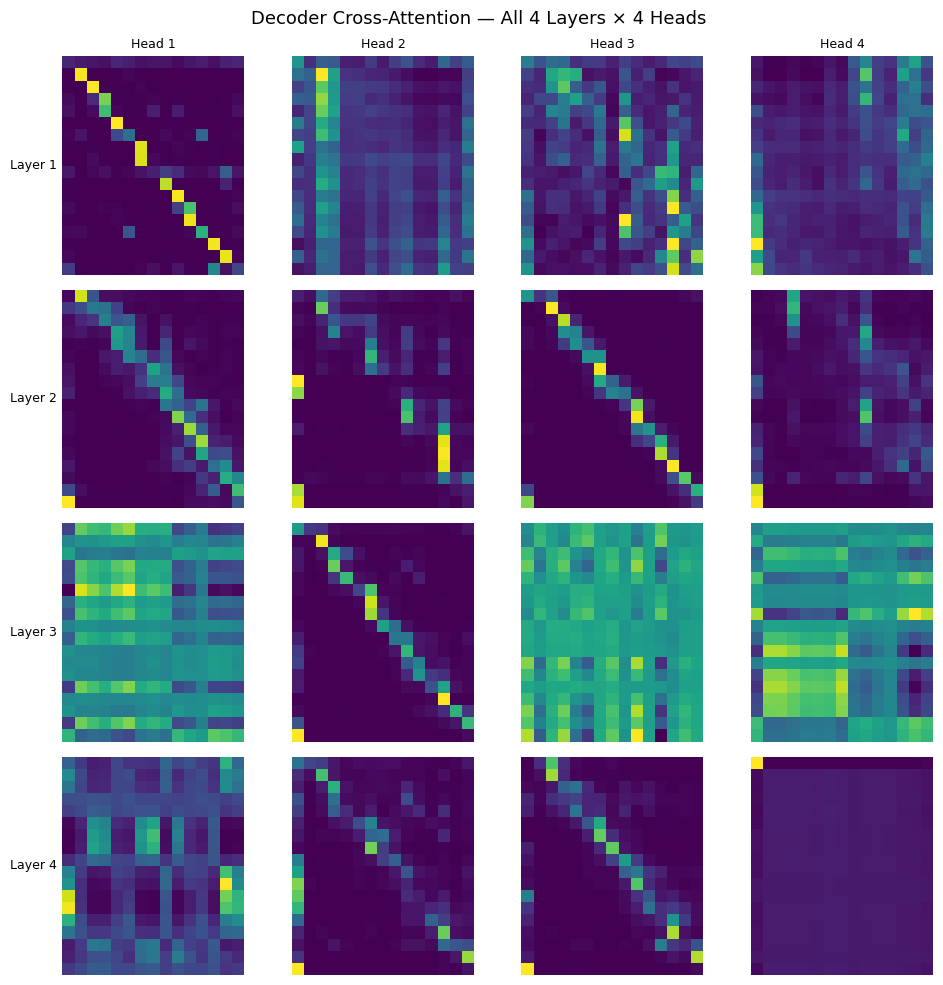

In [17]:
from visualization import plot_attention

# Grid of every decoder layer x every head at once, instead of one at a time.
# attn_type="cross" = decoder attending to source (same relation as the single
# heatmap above); "self" = decoder attending to its own previous tokens.
test_sentence = "Die Katze sitzt auf der Matte und schaut aus dem Fenster."

plot_attention(
    model=model,
    src_sentence=test_sentence,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    attn_type="cross",
    layer_idx=None,
    head_idx=None,
    save_path=None
)

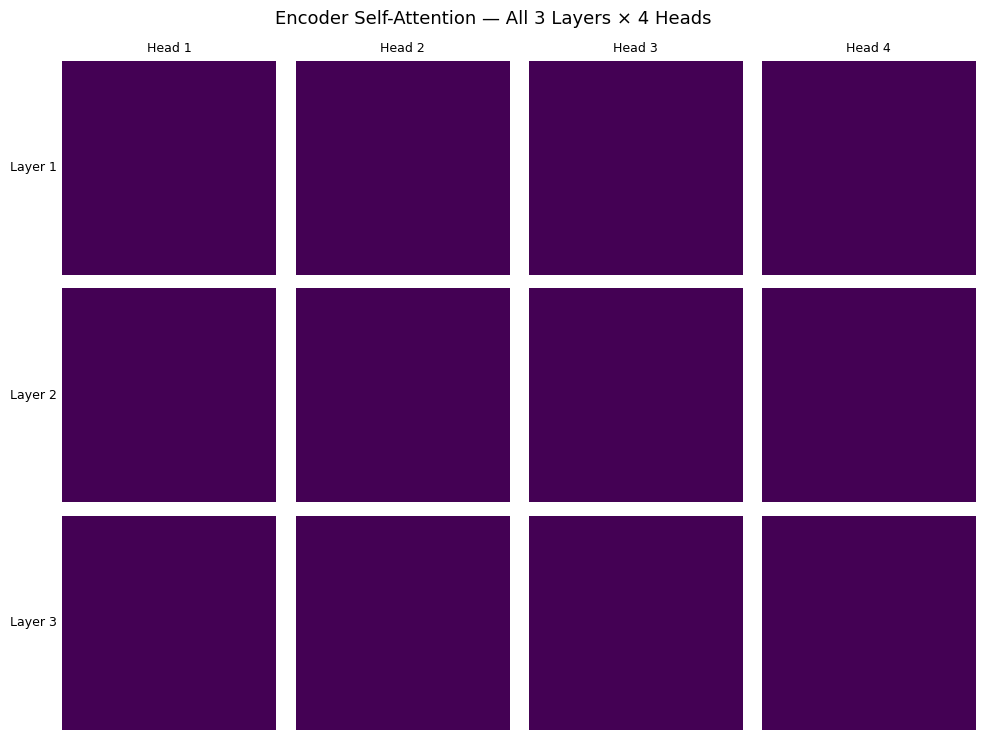

In [18]:
# Encoder self-attention — source tokens attending to each other. model.py's
# EncoderLayer.forward now captures and returns its attention weights too
# (enc_layer_{i}_self_attn), so this is plottable the same way as the decoder grids.
plot_attention(
    model=model,
    src_sentence=test_sentence,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    attn_type="encoder",
    layer_idx=None,
    head_idx=None,
    save_path=None
)

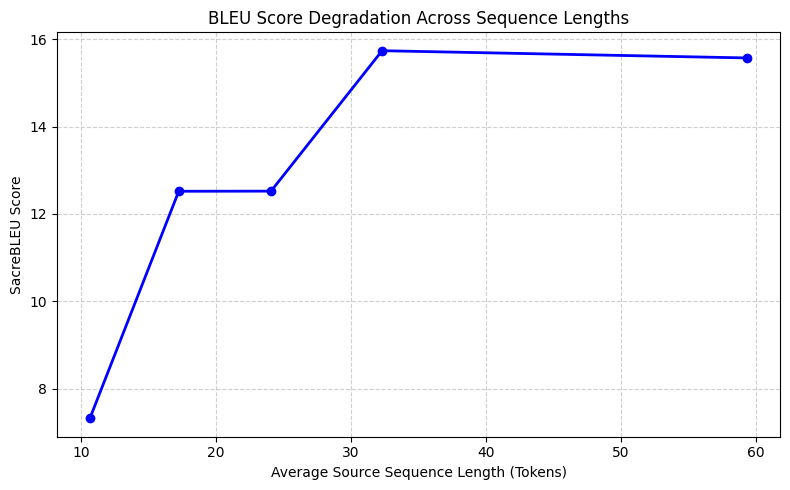

In [19]:
from evaluation import plot_bleu_vs_length

plot_bleu_vs_length(
    model=model,
    dataloader=val_loader,
    tgt_tokenizer=en_tok,
    device=device,
    max_len=50,
    num_bins=5
)